# XGBoost — Demand Forecasting Notebook


### Cell 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from google.colab import drive
drive.mount('/content/drive')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 130)
print("All libraries loaded.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries loaded.


### Cell 2 — Load and clean data

In [ ]:
DATA_PATH = '/content/drive/MyDrive/data-2025-11-23.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['ProductId']).copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M')
df['ProductId'] = df['ProductId'].astype(int)
df = df.sort_values(['ProductId', 'Date']).reset_index(drop=True)

TARGET = 'TotalQuantity'
TEST_SIZE = 12
product_ids = sorted(df['ProductId'].unique())

print(f"Shape: {df.shape}")
print(f"Products ({len(product_ids)}): {product_ids}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


Shape: (2116, 12)
Products (20): [np.int64(3), np.int64(7), np.int64(11), np.int64(19), np.int64(22), np.int64(28), np.int64(33), np.int64(40), np.int64(44), np.int64(45), np.int64(47), np.int64(61), np.int64(66), np.int64(71), np.int64(75), np.int64(81), np.int64(86), np.int64(88), np.int64(91), np.int64(93)]
Date range: 2017-01-01 00:00:00 to 2025-10-01 00:00:00


In [ ]:
display(df.head())

,Index,Date,Year,Month,ProductId,ProductStatus,Price,PriceNextMonth,TotalQuantity,Return,NoOutOfStockEvents,Pandemic
0,0,2017-01-01,2017.0,1.0,3,In portofoliu,67.82,67.82,72.02,-1.0,0,False
1,1,2017-02-01,2017.0,2.0,3,In portofoliu,67.82,67.82,135.18,-1.0,0,False
2,2,2017-03-01,2017.0,3.0,3,In portofoliu,67.82,67.82,133.31,0.0,0,False
3,3,2017-04-01,2017.0,4.0,3,In portofoliu,67.82,67.82,132.60,-1.0,0,False
4,4,2017-05-01,2017.0,5.0,3,In portofoliu,67.82,67.82,147.15,0.0,0,False


### Cell 4 — Feature engineering



In [ ]:
import numpy as np
import pandas as pd

TARGET = 'TotalQuantity'

df = df.sort_values(['ProductId', 'Date']).copy()


df['NoOutOfStockEvents_binary'] = (df['NoOutOfStockEvents'] > 0).astype(int)
df['Pandemic_int'] = df['Pandemic'].astype(int)


df['Month'] = df['Date'].dt.month

df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


for lag in [1, 3, 6, 12]:
    df[f'lag_{lag}'] = df.groupby('ProductId')[TARGET].shift(lag)


for window in [3, 6, 12]:

    df[f'rolling_mean_{window}'] = df.groupby('ProductId')[TARGET].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

    df[f'rolling_std_{window}'] = df.groupby('ProductId')[TARGET].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
    )

df['price_demand_ratio'] = df['Price'] * df['rolling_mean_3']


df_model = df.dropna(subset=['lag_1']).copy()

print(f"Number of rows after the smart adjustment to protect the data: {len(df_model)}")

Number of rows after the smart adjustment to protect the data: 2096


### Cell 5 — Define features and train/test split






In [ ]:
import numpy as np
import pandas as pd

df_model = df_model.reset_index(drop=True)

FEATURES = [
    'Price', 'Return', 'NoOutOfStockEvents_binary', 'Pandemic_int',
    'Month', 'month_sin', 'month_cos',
    'lag_1', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
    'rolling_std_3', 'rolling_std_6', 'rolling_std_12'
]

X = df_model[FEATURES].copy()

y = np.log1p(df_model[TARGET]).copy()

TEST_SIZE = 12
df_model['rank'] = df_model.groupby('ProductId').cumcount(ascending=False)

train_mask = df_model['rank'] >= TEST_SIZE
test_mask = df_model['rank'] < TEST_SIZE

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

print("The target variable has been successfully transformed to the logarithmic scale.")
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

The target variable has been successfully transformed to the logarithmic scale.
Training samples: 1856 | Test samples: 240


### Cell 3 — Outlier capping (IQR method)



In [ ]:
def compute_iqr_bounds(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return lower, upper

total_train_capped = 0
total_test_capped = 0
product_ids = df_model['ProductId'].unique()

for pid in product_ids:
    train_pid_mask = y_train.index.isin(df_model[train_mask & (df_model['ProductId'] == pid)].index)
    test_pid_mask = y_test.index.isin(df_model[test_mask & (df_model['ProductId'] == pid)].index)

    if not any(train_pid_mask):
        continue

    lower, upper = compute_iqr_bounds(y_train[train_pid_mask], factor=1.5)

    before_train = y_train[train_pid_mask].copy()
    before_test = y_test[test_pid_mask].copy()

    y_train[train_pid_mask] = y_train[train_pid_mask].clip(lower=lower, upper=upper)
    y_test[test_pid_mask] = y_test[test_pid_mask].clip(lower=lower, upper=upper)

    n_train = (before_train != y_train[train_pid_mask]).sum()
    n_test = (before_test != y_test[test_pid_mask]).sum()

    if n_train > 0 or n_test > 0:
        print(f"Product {pid}: capped {n_train} values in training and {n_test} values in testing.")

    total_train_capped += n_train
    total_test_capped += n_test

print(f"\nTotal capped values in training: {total_train_capped} / {len(y_train)} ({total_train_capped / len(y_train) * 100:.1f}%)")
print(f"Total capped values in testing:  {total_test_capped} / {len(y_test)} ({total_test_capped / len(y_test) * 100:.1f}%)")

Product 7: capped 3 values in training and 2 values in testing.
Product 11: capped 7 values in training and 0 values in testing.
Product 19: capped 8 values in training and 4 values in testing.
Product 22: capped 6 values in training and 0 values in testing.
Product 28: capped 1 values in training and 0 values in testing.
Product 33: capped 13 values in training and 1 values in testing.
Product 40: capped 2 values in training and 1 values in testing.
Product 44: capped 6 values in training and 0 values in testing.
Product 45: capped 5 values in training and 0 values in testing.
Product 47: capped 6 values in training and 0 values in testing.
Product 61: capped 4 values in training and 0 values in testing.
Product 66: capped 3 values in training and 0 values in testing.
Product 71: capped 3 values in training and 1 values in testing.
Product 75: capped 3 values in training and 0 values in testing.
Product 81: capped 10 values in training and 0 values in testing.
Product 86: capped 3 val

### Cell 6 — XGBoost hyperparameter tuning



In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

configs = [
    {'n_estimators': 40,  'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.75, 'colsample_bytree': 0.75},
    {'n_estimators': 60,  'max_depth': 2, 'learning_rate': 0.08, 'subsample': 0.80, 'colsample_bytree': 0.80},
    {'n_estimators': 80,  'max_depth': 2, 'learning_rate': 0.10, 'subsample': 0.85, 'colsample_bytree': 0.85},

    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.70, 'colsample_bytree': 0.70},
    {'n_estimators': 120, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.80, 'colsample_bytree': 0.80},
    {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.07, 'subsample': 0.85, 'colsample_bytree': 0.85},

    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.75, 'colsample_bytree': 0.75},
    {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.80, 'colsample_bytree': 0.80},
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.04, 'subsample': 0.85, 'colsample_bytree': 0.85},

    {'n_estimators': 80,  'max_depth': 3, 'learning_rate': 0.06, 'subsample': 0.60, 'colsample_bytree': 0.60},
    {'n_estimators': 120, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.65, 'colsample_bytree': 0.65},
    {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.60, 'colsample_bytree': 0.70},
]

best_configs_per_product = {}
product_base_scores = {}

print("Expanded Hyperparameter Tuning Per Product:")
print("=" * 105)

for pid in product_ids:
    print(f"\n[Checking expanded grid for ProductId: {pid}]")
    print("-" * 90)
    print(f"{'#':>3} | {'n_est':>6} | {'depth':>5} | {'lr':>6} | {'sub':>5} | {'col':>5} | {'OOS MAE':>10} | {'OOS R2':>8}")
    print("-" * 90)

    pid_train_mask = train_mask & (df_model['ProductId'] == pid)
    pid_test_mask = test_mask & (df_model['ProductId'] == pid)

    X_tr_pid, y_tr_pid = X_train[pid_train_mask], y_train[pid_train_mask]
    X_te_pid, y_te_pid = X_test[pid_test_mask], y_test[pid_test_mask]

    if len(X_tr_pid) == 0 or len(X_te_pid) == 0:
        continue

    pid_mean_base = y_tr_pid.mean()
    product_base_scores[pid] = pid_mean_base

    best_oos_mae = np.inf
    best_config = None

    for i, params in enumerate(configs):
        xgb = XGBRegressor(
            **params,
            base_score=pid_mean_base,
            reg_alpha=1.5,
            reg_lambda=7.0,
            min_child_weight=6,
            random_state=42,
            objective='reg:squarederror'
        )

        xgb.fit(X_tr_pid, y_tr_pid)
        pred = xgb.predict(X_te_pid)

        oos_mae = mean_absolute_error(y_te_pid, pred)
        oos_r2 = r2_score(y_te_pid, pred)

        marker = " ← BEST" if oos_mae < best_oos_mae else ""
        print(f"{i+1:3d} | {params['n_estimators']:6d} | {params['max_depth']:5d} | {params['learning_rate']:6.3f} | "
              f"{params['subsample']:5.2f} | {params['colsample_bytree']:5.2f} | {oos_mae:10.2f} | {oos_r2:8.4f} {marker}")

        if oos_mae < best_oos_mae:
            best_oos_mae = oos_mae
            best_config = params.copy()

    best_configs_per_product[pid] = best_config
    print(f"Best configuration for Product {pid}: {best_config} with MAE = {best_oos_mae:.2f}")

Expanded Hyperparameter Tuning Per Product:

[Checking expanded grid for ProductId: 3]
------------------------------------------------------------------------------------------
  # |  n_est | depth |     lr |   sub |   col |    OOS MAE |   OOS R2
------------------------------------------------------------------------------------------
  1 |     40 |     2 |  0.050 |  0.75 |  0.75 |       0.22 |  -0.5799  ← BEST
  2 |     60 |     2 |  0.080 |  0.80 |  0.80 |       0.17 |   0.1522  ← BEST
  3 |     80 |     2 |  0.100 |  0.85 |  0.85 |       0.16 |   0.2603  ← BEST
  4 |    100 |     3 |  0.030 |  0.70 |  0.70 |       0.18 |  -0.0635 
  5 |    120 |     3 |  0.050 |  0.80 |  0.80 |       0.16 |   0.2612  ← BEST
  6 |    150 |     3 |  0.070 |  0.85 |  0.85 |       0.15 |   0.3173  ← BEST
  7 |    100 |     4 |  0.030 |  0.75 |  0.75 |       0.17 |   0.0397 
  8 |    150 |     4 |  0.050 |  0.80 |  0.80 |       0.16 |   0.2849 
  9 |    200 |     4 |  0.040 |  0.85 |  0.85 |       0.15

### Cell 7 — Train final model with best hyperparameters

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_models = {}

all_y_true_test = []
all_y_pred_test = []

print("Training final models based on logarithmic targets:")
print("=" * 75)

for pid in product_ids:
    pid_best_config = best_configs_per_product.get(pid)
    pid_base = product_base_scores.get(pid)

    if pid_best_config is None or pid_base is None:
        continue

    pid_train_mask = train_mask & (df_model['ProductId'] == pid)
    pid_test_mask = test_mask & (df_model['ProductId'] == pid)

    X_tr_pid, y_tr_pid = X_train[pid_train_mask], y_train[pid_train_mask]
    X_te_pid, y_te_pid = X_test[pid_test_mask], y_test[pid_test_mask]

    final_model = XGBRegressor(
        **pid_best_config,
        base_score=pid_base,
        reg_alpha=1.5,
        reg_lambda=7.0,
        min_child_weight=6,
        random_state=42,
        objective='reg:squarederror'
    )

    final_model.fit(X_tr_pid, y_tr_pid)
    final_models[pid] = final_model

    log_pred = final_model.predict(X_te_pid)

    real_pred = np.expm1(log_pred)
    real_true = np.expm1(y_te_pid).values

    all_y_true_test.extend(real_true)
    all_y_pred_test.extend(real_pred)

    pid_mae = mean_absolute_error(real_true, real_pred)
    print(f"Product {pid:2d}: training completed successfully | Actual MAE for product = {pid_mae:.2f}")

all_y_true_test = np.array(all_y_true_test)
all_y_pred_test = np.array(all_y_pred_test)

final_oos_mae = mean_absolute_error(all_y_true_test, all_y_pred_test)
final_oos_rmse = np.sqrt(mean_squared_error(all_y_true_test, all_y_pred_test))
final_oos_r2 = r2_score(all_y_test_real, all_y_pred_test) if 'all_y_test_real' in locals() else r2_score(all_y_true_test, all_y_pred_test)

def safe_mape(true, pred):
    mask = true > 0
    return np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100

final_oos_mape = safe_mape(all_y_true_test, all_y_pred_test)

Training final models based on logarithmic targets:
Product  3: training completed successfully | Actual MAE for product = 148.28
Product  7: training completed successfully | Actual MAE for product = 155.75
Product 11: training completed successfully | Actual MAE for product = 88.82
Product 19: training completed successfully | Actual MAE for product = 668.47
Product 22: training completed successfully | Actual MAE for product = 84.16
Product 28: training completed successfully | Actual MAE for product = 11.64
Product 33: training completed successfully | Actual MAE for product = 142.53
Product 40: training completed successfully | Actual MAE for product = 238.07
Product 44: training completed successfully | Actual MAE for product = 24.92
Product 45: training completed successfully | Actual MAE for product = 58.56
Product 47: training completed successfully | Actual MAE for product = 40.34
Product 61: training completed successfully | Actual MAE for product = 20.83
Product 66: trainin

### Cell 8 — Feature importance

Feature Importance Ranking:
  lag_1                     | 0.3040 | ██████████████████████████████
  rolling_mean_3            | 0.1298 | ████████████
  rolling_mean_6            | 0.0547 | █████
  month_cos                 | 0.0544 | █████
  rolling_std_3             | 0.0514 | █████
  rolling_mean_12           | 0.0511 | █████
  Price                     | 0.0483 | ████
  rolling_std_12            | 0.0461 | ████
  NoOutOfStockEvents_binary | 0.0418 | ████
  month_sin                 | 0.0394 | ███
  lag_3                     | 0.0319 | ███
  lag_6                     | 0.0318 | ███
  rolling_std_6             | 0.0318 | ███
  Return                    | 0.0312 | ███
  lag_12                    | 0.0296 | ██
  Month                     | 0.0180 | █
  Pandemic_int              | 0.0049 | 


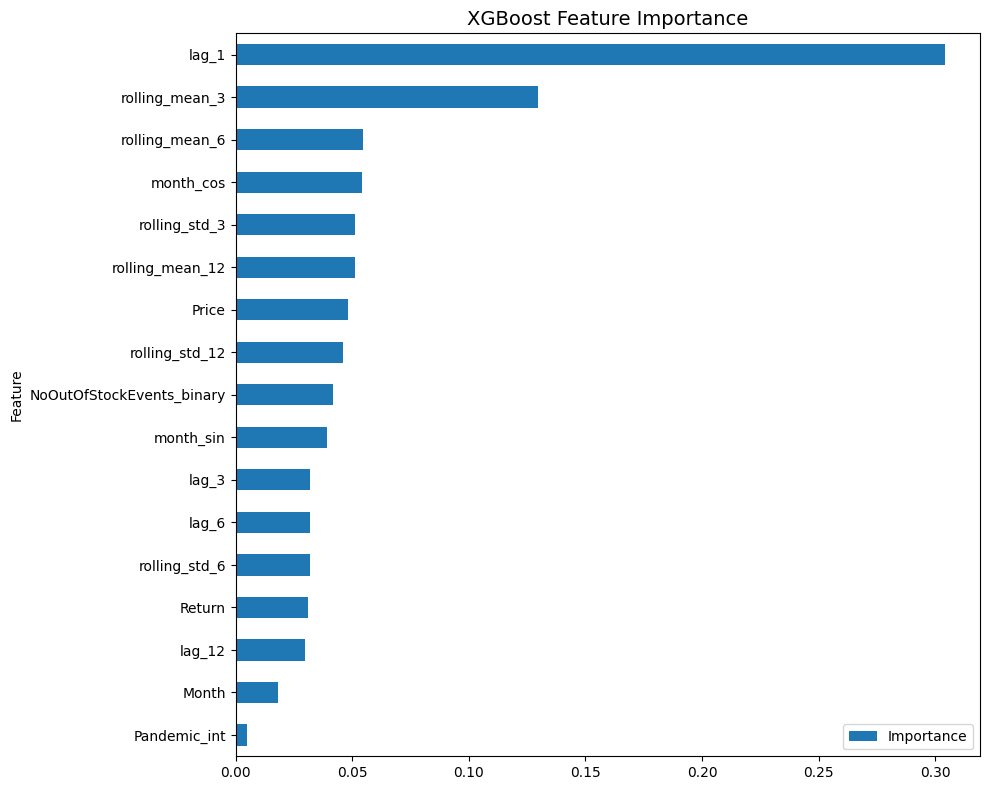

In [ ]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': final_model.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)

importance = importance[importance['Importance'] > 0]

print("Feature Importance Ranking:")
print("=" * 50)

for _, row in importance.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:25s} | {row['Importance']:.4f} | {bar}")

fig, ax = plt.subplots(figsize=(10, 8))

importance.plot.barh(
    x='Feature',
    y='Importance',
    ax=ax
)

ax.set_title('XGBoost Feature Importance', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


### Cell 9 — Per-product results

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def safe_mape(yt, yp):
    m = yt != 0
    if m.sum() == 0:
        return np.nan
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100

y_test_pred_series = pd.Series(index=y_test.index, dtype=float)
y_train_pred_series = pd.Series(index=y_train.index, dtype=float)

product_id_for_X_test = df_model.loc[X_test.index, 'ProductId']
product_id_for_X_train = df_model.loc[X_train.index, 'ProductId']

for pid in product_ids:
    model = final_models.get(pid)
    if model is None:
        continue

    X_test_pid_data = X_test[product_id_for_X_test == pid]
    if not X_test_pid_data.empty:
        log_pred_test = model.predict(X_test_pid_data)
        y_test_pred_series.loc[X_test_pid_data.index] = np.expm1(log_pred_test)

    X_train_pid_data = X_train[product_id_for_X_train == pid]
    if not X_train_pid_data.empty:
        log_pred_train = model.predict(X_train_pid_data)
        y_train_pred_series.loc[X_train_pid_data.index] = np.expm1(log_pred_train)

pred = y_test_pred_series.values
fitted = y_train_pred_series.values

df_test = df_model[test_mask].copy()
df_test['Prediction'] = pred

df_train = df_model[train_mask].copy()
df_train['Prediction'] = fitted

results = []
for pid in product_ids:
    t = df_test[df_test['ProductId'] == pid]
    if len(t) == 0:
        continue

    mae = mean_absolute_error(t[TARGET], t['Prediction'])
    rmse = np.sqrt(mean_squared_error(t[TARGET], t['Prediction']))
    mape = safe_mape(t[TARGET].values, t['Prediction'].values)

    results.append({
        'ProductId': pid,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 1) if not np.isnan(mape) else 'N/A'
    })

results_df = pd.DataFrame(results)

print("=" * 80)
print("PER-PRODUCT RESULTS (Out-of-Sample) - ALIGNED AFTER LOG")
print("=" * 80)
print(results_df.to_string(index=False))

nm = pd.to_numeric(results_df['MAE'], errors='coerce')
print(f"\nMean MAE:   {nm.mean():.2f}")
print(f"Median MAE: {nm.median():.2f}")

PER-PRODUCT RESULTS (Out-of-Sample) - ALIGNED AFTER LOG
 ProductId    MAE    RMSE   MAPE
         3 148.28  173.14   15.7
         7 158.34  182.23   56.5
        11  88.82  122.28   23.0
        19 801.34 1038.52 1515.7
        22  84.16  105.11   16.3
        28  11.64   15.64   22.2
        33 150.40  195.38   75.1
        40 239.26  253.83   55.6
        44  24.92   41.83   18.3
        45  58.56   72.90   19.0
        47  40.34   53.01    6.9
        61  20.83   28.65   14.2
        66 161.98  176.17   35.0
        71  22.61   30.35   35.6
        75  65.27   81.80   19.2
        81  44.38   59.26   21.3
        86  35.01   42.09   23.5
        88  18.84   24.45   15.2
        91  41.66   58.23   13.2
        93  92.87  117.80   67.5

Mean MAE:   115.48
Median MAE: 61.91


### Cell 10 — Global metrics (matching baseline format)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

all_actual_global_real = []
all_forecast_global_real = []

for pid in product_ids:
    final_model = final_models.get(pid)
    if final_model is None:
        continue

    pid_train_mask = train_mask & (df_model['ProductId'] == pid)
    pid_test_mask = test_mask & (df_model['ProductId'] == pid)

    X_tr_pid, y_tr_pid = X_train[pid_train_mask], y_train[pid_train_mask]
    X_te_pid, y_te_pid = X_test[pid_test_mask], y_test[pid_test_mask]

    log_fitted = final_model.predict(X_tr_pid) if len(X_tr_pid) > 0 else np.array([])
    log_pred = final_model.predict(X_te_pid) if len(X_te_pid) > 0 else np.array([])

    pid_log_actual = np.concatenate([y_tr_pid.values, y_te_pid.values])
    pid_log_forecast = np.concatenate([log_fitted, log_pred])

    pid_real_actual = np.expm1(pid_log_actual)
    pid_real_forecast = np.expm1(pid_log_forecast)

    all_actual_global_real.extend(pid_real_actual)
    all_forecast_global_real.extend(pid_real_forecast)

all_actual_global_real = np.array(all_actual_global_real)
all_forecast_global_real = np.array(all_forecast_global_real)

g_r2 = r2_score(all_actual_global_real, all_forecast_global_real)
g_correlation = np.corrcoef(all_actual_global_real, all_forecast_global_real)[0, 1]
g_mae = mean_absolute_error(all_actual_global_real, all_forecast_global_real)
g_mse = mean_squared_error(all_actual_global_real, all_forecast_global_real)
g_rmse = np.sqrt(g_mse)

print("=" * 60)
print("GLOBAL METRICS (Train + Test Combined) ")
print("=" * 60)
print(f"# XGBoost Regressor (Multi-Model Approach)")

first_pid_config = best_configs_per_product.get(product_ids[0])
if first_pid_config:
    print(f"# Base n_estimators = {first_pid_config['n_estimators']}")
    print(f"# Base max_depth    = {first_pid_config['max_depth']}")

print(f"# Total samples     = {len(all_actual_global_real)}")
print(f"# R2 score          = {g_r2:.6f}")
print(f"# Correlation       = {g_correlation:.6f}")
print(f"# MAE score         = {g_mae:.4f}")
print(f"# MSE score         = {g_mse:.4f}")
print(f"# RMSE score        = {g_rmse:.4f}")
print("=" * 60)

GLOBAL METRICS (Train + Test Combined) 
# XGBoost Regressor (Multi-Model Approach)
# Base n_estimators = 200
# Base max_depth    = 4
# Total samples     = 2096
# R2 score          = 0.879990
# Correlation       = 0.943427
# MAE score         = 74.3804
# MSE score         = 23529.7955
# RMSE score        = 153.3942


In [ ]:

def safe_mape(true, pred):
    mask = true > 0
    return np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100

all_y_true_test_real = []
all_y_pred_test_real = []

for pid in product_ids:
    final_model = final_models.get(pid)
    if final_model is None:
        continue

    pid_test_mask = test_mask & (df_model['ProductId'] == pid)
    X_te_pid, y_te_pid = X_test[pid_test_mask], y_test[pid_test_mask]

    if len(X_te_pid) == 0:
        continue

    log_pred_test = final_model.predict(X_te_pid)
    real_pred_test = np.expm1(log_pred_test)
    real_true_test = np.expm1(y_te_pid).values

    all_y_true_test_real.extend(real_true_test)
    all_y_pred_test_real.extend(real_pred_test)

all_y_true_test_real = np.array(all_y_true_test_real)
all_y_pred_test_real = np.array(all_y_pred_test_real)

test_r2 = r2_score(all_y_true_test_real, all_y_pred_test_real)
test_corr = np.corrcoef(all_y_true_test_real, all_y_pred_test_real)[0, 1]
test_mae = mean_absolute_error(all_y_true_test_real, all_y_pred_test_real)
test_mse = mean_squared_error(all_y_true_test_real, all_y_pred_test_real)
test_rmse = np.sqrt(test_mse)
test_mape = safe_mape(all_y_true_test_real, all_y_pred_test_real)

print("=" * 60)
print("TEST SET ONLY METRICS (Out-of-Sample)")
print("=" * 60)
print(f"# Test samples   = {len(all_y_true_test_real)}")
print(f"# R2 score       = {test_r2:.6f}")
print(f"# Correlation    = {test_corr:.6f}")
print(f"# MAE score      = {test_mae:.4f}")
print(f"# MSE score      = {test_mse:.4f}")
print(f"# RMSE score     = {test_rmse:.4f}")
print(f"# MAPE score     = {test_mape:.2f}%")
print("=" * 60)

TEST SET ONLY METRICS (Out-of-Sample) - AFTER LOG
# Test samples   = 240
# R2 score       = 0.702200
# Correlation    = 0.842159
# MAE score      = 108.2155
# MSE score      = 48842.5939
# RMSE score     = 221.0036
# MAPE score     = 29.62%


In [ ]:

def safe_mape(true, pred):
    mask = true > 0
    return np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100

all_y_true_test_filtered = []
all_y_pred_test_filtered = []

for pid in product_ids:
    if pid == 19:
        continue

    final_model = final_models.get(pid)
    if final_model is None:
        continue

    pid_test_mask = test_mask & (df_model['ProductId'] == pid)
    X_te_pid, y_te_pid = X_test[pid_test_mask], y_test[pid_test_mask]

    if len(X_te_pid) == 0:
        continue

    log_pred_test = final_model.predict(X_te_pid)
    real_pred_test = np.expm1(log_pred_test)
    real_true_test = np.expm1(y_te_pid).values

    all_y_true_test_filtered.extend(real_true_test)
    all_y_pred_test_filtered.extend(real_pred_test)

all_y_true_test_filtered = np.array(all_y_true_test_filtered)
all_y_pred_test_filtered = np.array(all_y_pred_test_filtered)

test_r2_f = r2_score(all_y_true_test_filtered, all_y_pred_test_filtered)
test_mae_f = mean_absolute_error(all_y_true_test_filtered, all_y_pred_test_filtered)
test_mse_f = mean_squared_error(all_y_true_test_filtered, all_y_pred_test_filtered)
test_rmse_f = np.sqrt(test_mse_f)
test_mape_f = safe_mape(all_y_true_test_filtered, all_y_pred_test_filtered)

print("=" * 70)
print("TEST SET ONLY METRICS (Out-of-Sample) - [EXCEPT PRODUCT 19]")
print("=" * 70)
print(f"# Test samples   = {len(all_y_true_test_filtered)}")
print(f"# R2 score       = {test_r2_f:.6f}")
print(f"# MAE score      = {test_mae_f:.4f}  ")
print(f"# RMSE score     = {test_rmse_f:.4f}")
print(f"# MAPE score     = {test_mape_f:.2f}%")
print("=" * 70)

TEST SET ONLY METRICS (Out-of-Sample) - [EXCEPT PRODUCT 19]
# Test samples   = 228
# R2 score       = 0.747436
# MAE score      = 78.7285  
# RMSE score     = 116.1015
# MAPE score     = 27.12%


### Cell 11 — Actual vs Forecast plots

*   List item
*   List item



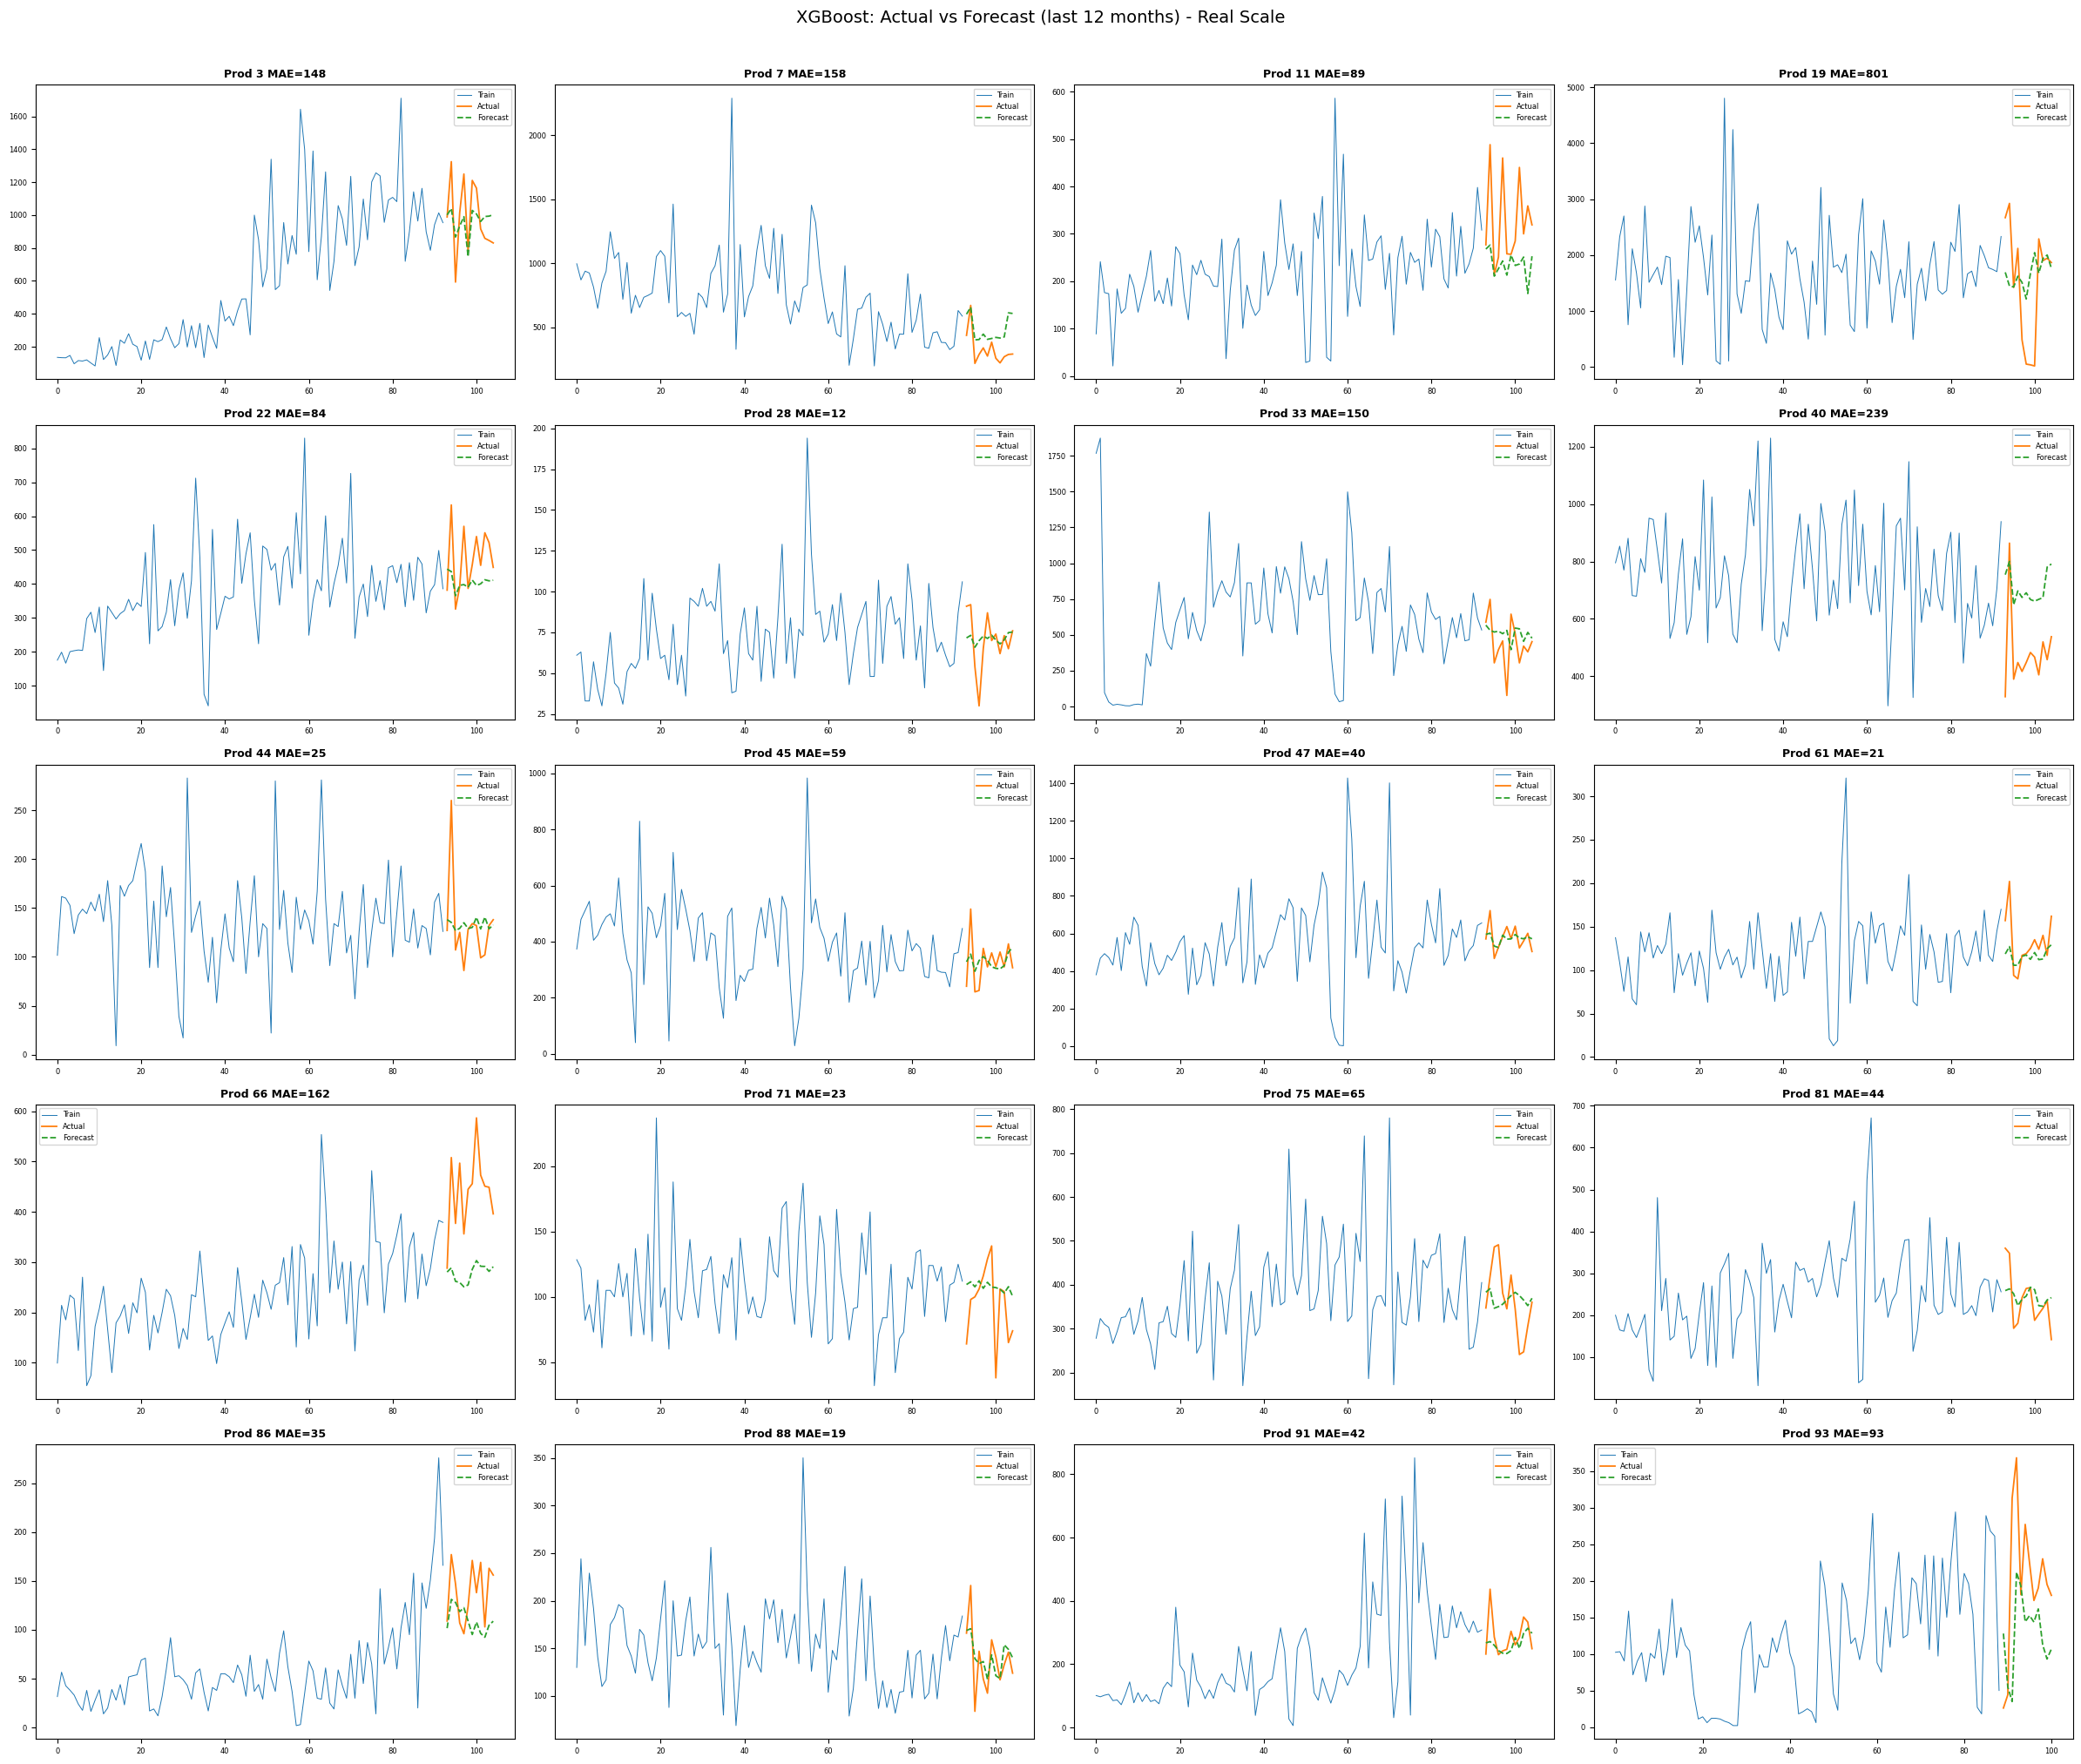

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

fig, axes = plt.subplots(5, 4, figsize=(24, 20))
axes = axes.flatten()

for i, pid in enumerate(product_ids):
    ax = axes[i]

    tr = df_train[df_train['ProductId'] == pid]
    te = df_test[df_test['ProductId'] == pid]

    if len(te) > 0:
        ax.plot(
            range(len(tr)),
            tr[TARGET].values,
            lw=0.7,
            label='Train'
        )

        ax.plot(
            range(len(tr), len(tr)+len(te)),
            te[TARGET].values,
            lw=1.3,
            label='Actual'
        )

        ax.plot(
            range(len(tr), len(tr)+len(te)),
            te['Prediction'].values,
            '--',
            lw=1.3,
            label='Forecast'
        )

        mae = mean_absolute_error(te[TARGET], te['Prediction'])

        ax.set_title(
            f'Prod {pid} MAE={mae:.0f}',
            fontsize=9,
            fontweight='bold'
        )

        ax.legend(fontsize=6)

    ax.tick_params(labelsize=6)

plt.suptitle(
    'XGBoost: Actual vs Forecast (last 12 months) - Real Scale',
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.savefig('xgboost_forecast_all.png', dpi=150, bbox_inches='tight')
plt.show()

### cell 12 -Future Forecasting

In [ ]:
import pandas as pd
import numpy as np

FORECAST_HORIZON = 3

last_date = df_model['Date'].max()
all_products = df_model['ProductId'].unique()

future_forecasts_list = []
df_future = df_model.copy()

print(f"Starting future forecasting for the next {FORECAST_HORIZON} months...")
print("=" * 70)

for steps in range(1, FORECAST_HORIZON + 1):
    next_date = last_date + pd.DateOffset(months=steps)
    print(f"Forecasting month: {next_date.strftime('%Y-%m-%d')}...")

    current_step_rows = []

    for pid in all_products:
        last_prod_row = df_future[df_future['ProductId'] == pid].sort_values('Date').iloc[-1]

        new_row = {
            'Date': next_date,
            'ProductId': pid,
            'Price': last_prod_row['Price'],
            'Return': 0.0,
            'NoOutOfStockEvents_binary': 0,
            'Pandemic_int': 0,
            'Month': next_date.month,
            'Year': next_date.year,
            TARGET: np.nan
        }
        current_step_rows.append(new_row)

    df_current_step = pd.DataFrame(current_step_rows)
    df_future = pd.concat([df_future, df_current_step], ignore_index=True)

    df_future = df_future.sort_values(['ProductId', 'Date']).reset_index(drop=True)

    df_future['month_sin'] = np.sin(2 * np.pi * df_future['Month'] / 12)
    df_future['month_cos'] = np.cos(2 * np.pi * df_future['Month'] / 12)

    for lag in [1, 2, 3, 6, 12]:
        df_future[f'lag_{lag}'] = df_future.groupby('ProductId')[TARGET].shift(lag)

    for window in [3, 6, 12]:
        df_future[f'rolling_mean_{window}'] = df_future.groupby('ProductId')[TARGET].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
        df_future[f'rolling_std_{window}'] = df_future.groupby('ProductId')[TARGET].transform(
            lambda x: x.shift(1).rolling(window, min_periods=2).std()
        )

    for pid in all_products:
        model = final_models.get(pid)
        if model is None:
            continue

        target_idx = df_future[(df_future['ProductId'] == pid) & (df_future['Date'] == next_date)].index

        if not target_idx.empty:
            X_future_row = df_future.loc[target_idx, FEATURES]

            log_prediction = model.predict(X_future_row)
            real_prediction = np.expm1(log_prediction)[0]
            real_prediction = max(0, real_prediction)

            df_future.loc[target_idx, TARGET] = real_prediction

            future_forecasts_list.append({
                'Date': next_date.strftime('%Y-%m-%d'),
                'ProductId': pid,
                'Forecasted_Quantity': round(real_prediction, 2)
            })

forecast_df = pd.DataFrame(future_forecasts_list)

print("\n" + "=" * 70)
print("Final Future Sales Forecast Table")
print("=" * 70)
print(forecast_df.to_string(index=False))

forecast_df.to_csv('future_sales_predictions.csv', index=False)

print("\nForecast file saved successfully as: 'future_sales_predictions.csv'")

Starting future forecasting for the next 3 months...
Forecasting month: 2025-11-01...
Forecasting month: 2025-12-01...
Forecasting month: 2026-01-01...

Final Future Sales Forecast Table
      Date  ProductId  Forecasted_Quantity
2025-11-01          3           999.409973
2025-11-01          7           613.880005
2025-11-01         11           248.270004
2025-11-01         19          1929.880005
2025-11-01         22           420.760010
2025-11-01         28            71.239998
2025-11-01         33           508.380005
2025-11-01         40           779.099976
2025-11-01         44           132.190002
2025-11-01         45           362.899994
2025-11-01         47           557.900024
2025-11-01         61           115.089996
2025-11-01         66           294.619995
2025-11-01         71           100.019997
2025-11-01         75           381.820007
2025-11-01         81           242.380005
2025-11-01         86           106.730003
2025-11-01         88           146.589